In [1]:
import warnings; warnings.filterwarnings(action='ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from binance import Client

In [2]:
client = Client()
def get_tickers():
    tickers = []
    for info in client.futures_mark_price():
        ticker = info['symbol']
        if ticker[-4:] == "USDT":
            tickers.append(info['symbol'])
    return tickers

def get_sample(ticker, start_date="1 Jan, 2021"):
    klines = np.array(client.futures_historical_klines(ticker, Client.KLINE_INTERVAL_1DAY, start_date))
    sample = pd.DataFrame(klines.reshape(-1, 12), dtype=float, columns=['datetime',
                                                                        'open', 
                                                                        'high', 
                                                                        'low', 
                                                                        'close', 
                                                                        'volume', 
                                                                        'close time', 
                                                                        'quote asset volume, number of trades', 
                                                                        'number of trades',
                                                                        'taker buy base asset volume', 
                                                                        'taker buy quote asset volume', 
                                                                        'ignore'])
    sample['datetime'] = pd.to_datetime(sample['datetime'], unit='ms')
    sample.set_index('datetime', inplace=True)
    sample = sample[['open', 'high', 'low', 'close', 'volume']].copy()
    return sample

sample = get_sample("BTCUSDT")
sample.tail()

,open,high,low,close,volume
datetime,,,,,
2022-01-10,41851.22,42219.84,39610.00,41801.55,453644.116
2022-01-11,41801.55,43118.00,41255.00,42700.68,323760.691
2022-01-12,42700.69,44300.00,42415.00,43880.72,281339.294
2022-01-13,43880.72,44396.68,42301.16,42534.32,289289.180
2022-01-14,42538.72,42950.70,42340.00,42596.82,70790.555


In [3]:
tickers = get_tickers()
samples = dict()
for ticker in tickers:
    sample = get_sample(ticker, start_date="1 Jan, 2020")
    if len(sample) < 50: continue
    
    # preprocess
    sample['mom3'] = (sample['close'] - sample.shift(3)['close'])/sample.shift(3)['close']
    sample['mom7'] = (sample['close'] - sample.shift(7)['close'])/sample.shift(7)['close']
    sample['mom10'] = (sample['close'] - sample.shift(10)['close'])/sample.shift(10)['close']
    sample['mom14'] = (sample['close'] - sample.shift(14)['close'])/sample.shift(14)['close']
    sample['mom20'] = (sample['close'] - sample.shift(20)['close'])/sample.shift(20)['close']
    #sample['mom72'] = (sample['close'] - sample.shift(72)['close'])/sample.shift(72)['close']
    sample['reward'] = 1. + sample['close'].pct_change()
    sample['total_reward'] = sample['reward'].cumprod()
    sample.dropna(inplace=True)
    
    samples[ticker] = sample.copy(); del sample
samples['ETHUSDT'].tail(10)

,open,high,low,close,volume,mom3,mom7,mom10,mom14,mom20,reward,total_reward
datetime,,,,,,,,,,,,
2022-01-05,3785.60,3847.18,3405.00,3537.71,1813981.948,-0.075401,-0.025035,-0.129123,-0.110820,-0.106339,0.934518,27.083984
2022-01-06,3537.81,3549.11,3292.31,3404.60,1840489.348,-0.095500,-0.081915,-0.156726,-0.171892,-0.121151,0.962374,26.064921
2022-01-07,3404.61,3415.35,3040.77,3196.58,2855226.352,-0.155595,-0.130424,-0.157018,-0.209745,-0.192301,0.938900,24.472363
2022-01-08,3196.58,3248.03,2996.45,3080.03,1859886.155,-0.129372,-0.181509,-0.151168,-0.247648,-0.214781,0.963539,23.580080
2022-01-09,3079.86,3209.40,3057.00,3150.00,1230848.792,-0.074781,-0.176731,-0.150570,-0.224566,-0.201213,1.022717,24.115756
2022-01-10,3149.99,3179.16,2924.78,3081.31,2322294.565,-0.036060,-0.181389,-0.161781,-0.236801,-0.232432,0.978194,23.589879
2022-01-11,3081.25,3262.66,3050.58,3236.86,1533503.746,0.050918,-0.144955,-0.139833,-0.146395,-0.186437,1.050482,24.780738
2022-01-12,3236.86,3411.00,3203.85,3369.93,1435454.649,0.069819,-0.047426,-0.119251,-0.071274,-0.180325,1.041111,25.799495
2022-01-13,3369.92,3408.89,3230.97,3240.36,1374273.064,0.051618,-0.048241,-0.139134,-0.126204,-0.198922,0.961551,24.807533


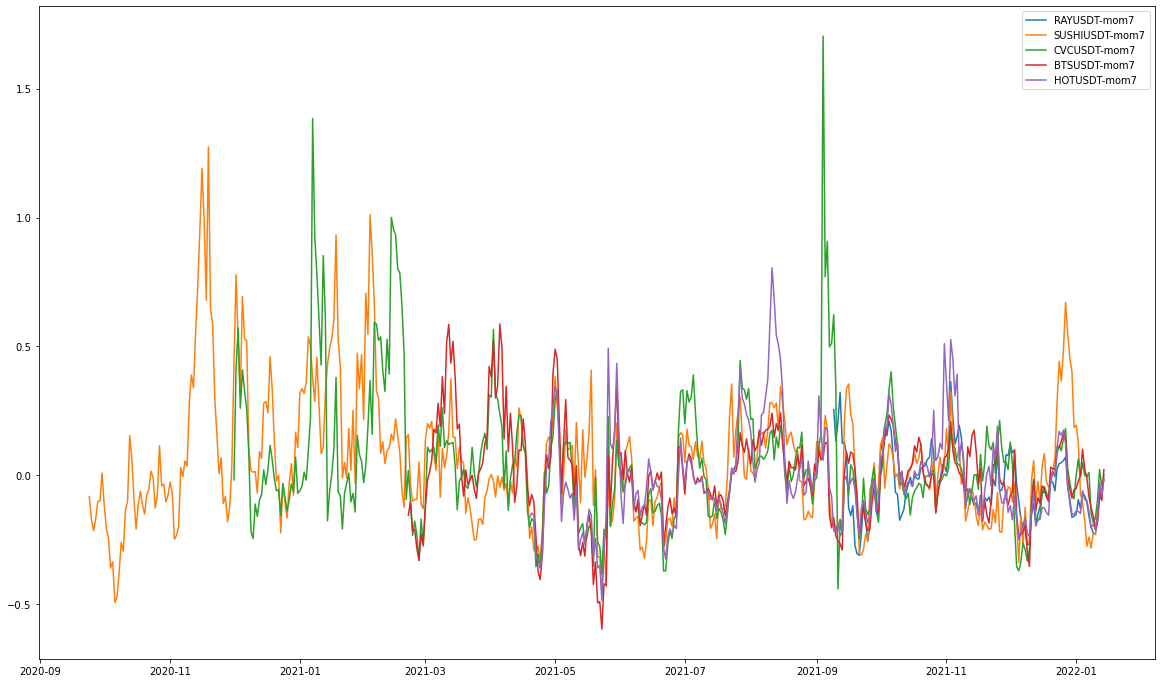

In [4]:
plt.figure(figsize=(20, 12))
for ticker in list(samples.keys())[:5]:
    plt.plot(samples[ticker].index, samples[ticker].mom7, label=f"{ticker}-mom7")
plt.legend(loc='best')
plt.show()

In [9]:
book = samples['ETHUSDT'][['close']].copy()
book['number'] = book.index.map(mdates.date2num)
book['reward'] = 1. 
book['momentum'] = 1.

for idx in book.index[:-1]:
    # select 21 highest volume coins
    volumes = dict()
    for ticker in tickers:
        try:
            volumes[ticker] = samples[ticker].loc[idx, 'close']*samples[ticker].loc[idx, 'volume']
        except:
            continue
    top21v = dict(sorted(volumes.items(), key=(lambda x: x[1]), reverse=True)[:21])
    
    
    # select 5 highest momentum coins
    momentums = dict()
    for ticker in top21v.keys():
        try:
            momentums[ticker] = samples[ticker].loc[idx, 'mom20']
        except:
            continue
    top5 = dict(sorted(momentums.items(), key=(lambda x: x[1]), reverse=True)[:4])
    
    reward = 0.
    ratio = 1./len(top5)
    
    for coin in top5.keys():
        #lev = 0
        #if samples[coin].loc[idx, 'mom3'] > 0.5:  lev += 1
        #if samples[coin].loc[idx, 'mom7'] > 0.5 or samples[coin].loc[idx, 'mom7'] < -0.3:  lev += 1
        #if samples[coin].loc[idx, 'mom10'] > 0.4: lev += 1
        #if samples[coin].loc[idx, 'mom14'] > 0.2: lev += 1
        #if samples[coin].loc[idx, 'mom20'] > 0.1:  lev += 1
        #if samples[coin].loc[idx, 'mom72'] > 0.:   lev += 1
        #if samples[coin].loc[idx, 'mom20'] > 0.1 and samples[coin].loc[idx, 'mom7'] > 0.5: lev = 2
        
        lev = 0
        if samples[coin].loc[idx, 'mom7'] > 0.5: lev += 1
        if samples[coin].loc[idx, 'mom7'] < -0.4: lev += 1
        if samples[coin].loc[idx, 'mom20'] > 0.1: lev += 1
        
        # ETH filtering0000000000
        #if samples['BTCUSDT'].loc[idx, 'mom20'] > 0.03:
        #    if samples['ETHUSDT'].loc[idx, 'mom7'] > samples[coin].loc[idx, 'mom7']:
        #        this_reward = samples['ETHUSDT'].shift(-1).loc[idx, 'reward'] - 1.003
        #    else:
        this_reward = lev*(samples[coin].shift(-1).loc[idx, 'reward']-1.003)
        #else:
        #    this_reward = 0.
        reward += ratio*(1. + this_reward)
    
    #if samples['ETHUSDT'].loc[idx, 'mom7'] < 0.:    reward = 1.
    book.loc[idx, 'reward'] = reward
book.dropna(inplace=True)

# evaluate
total_reward = 1.
for idx in book.index:
    total_reward *= book.loc[idx, 'reward']
    book.loc[idx, 'total_reward'] = total_reward
CAGR = book['total_reward'].iloc[-1]**(365./len(book.index)) - 1.

historical_max = book['total_reward'].cummax()
daily_drawdown = book['total_reward']/historical_max - 1.
historical_dd = daily_drawdown.cummin()
MDD = historical_dd.min()
VOL = np.std(book['reward'])*np.sqrt(365.)
Sharpe = (np.mean(book['reward'])/np.std(book['reward'])*np.sqrt(365.))

print("==== Dual Momentum ====")
print("Accumulated Returns:", round((total_reward-1.)*100, 2), "%")
print("CAGR:", round(CAGR*100, 2), "%")
print("MDD:", round(MDD*100, 2), "%")
print("VOL:", round(VOL*100, 3), "%")
print("Sharpe:", round(Sharpe*100,2), "%")

==== Dual Momentum ====
Accumulated Returns: 463866.65 %
CAGR: 6912.72 %
MDD: -71.61 %
VOL: 206.313 %
Sharpe: 17994.22 %


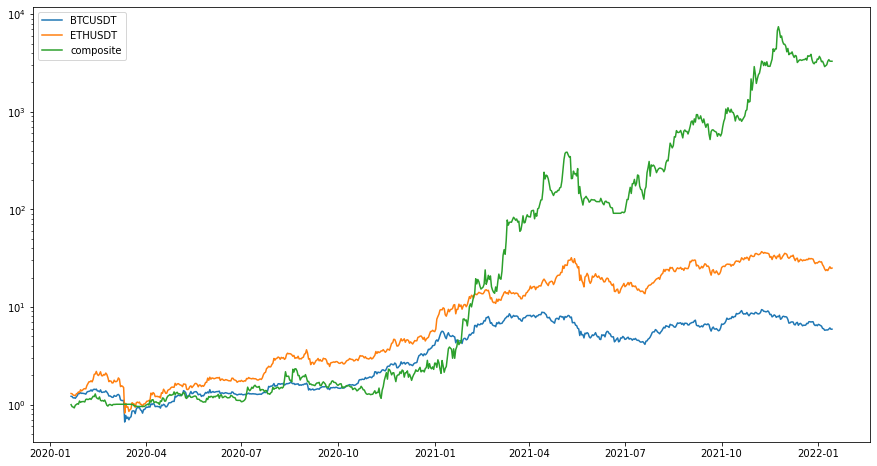

In [8]:
plt.figure(figsize=(15, 8))
plt.yscale('log')
plt.plot(samples['BTCUSDT'].index, samples['BTCUSDT'].total_reward, label="BTCUSDT")
plt.plot(samples['ETHUSDT'].index, samples['ETHUSDT'].total_reward, label="ETHUSDT")
plt.plot(book.index, book.total_reward, label='composite')
plt.legend(loc='best')

plt.show()